In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("clientes_ventas_sucio.csv", encoding='utf-8-sig')

print(f"filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

filas: 5,210 | Columnas: 17


In [4]:
df.head()

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
0,1.0,Sergio Gómez,usuario1@empresa.co,NaN,22,F,CALI,Tecnología,47123.36,3348625.06,9.5,Tarjeta Débito,2020-03-04,06-01-2023,Pendiente,16.0,Oriente
1,2.0,Carlos González,usuario2@hotmail.com,NaN,35,Femenino,Cartagena,Ropa,41641.38,2807157.91,6.6,PSE,17/01/2022,28/06/2020,Cancelado,23.0,NaN
2,3.0,Juan Gómez,usuario3gmail.com,3012512204,31,Femenino,Cali,ROPA,133145.84,3586614.16,7.9,Tarjeta Crédito,01-11-2020,30-06-2024,Inactivo,34.0,Sur
3,4.0,Paola López,usuario4@outlook.com,3153714180,64,M,Bucaramanga,Electrónica,357533.52,2657708.20,NaN,Nequi,2022-03-10,19-01-2023,Pendiente,29.0,Sur
4,5.0,Sandra González,NaN,3158003954,54,Male,Bogotá,Alimentos,5327.67,3991891.30,2.2,Efectivo,22/05/2023,09-19-2022,Inactivo,33.0,Sur


In [5]:
df.tail(15)

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
5195,582.0,Natalia Ramírez,sin_email,3115120387,25,F,Pereira,ROPA,86398.07,3773460.27,8.0,TARJETA CREDITO,13-08-2024,03 Feb 2024,Pendiente,8.0,Oriente
5196,483.0,Juan Sánchez,usuario483@yahoo.com,3107331506,52,Female,Barranquilla,Tecnología,650713.78,1922937.33,NaN,PSE,04 Apr 2022,11 Dec 2020,Activo,44.0,Occidente
5197,1876.0,Juan Gómez,usuario1876@empresa.co,3008008179,31,Male,Barranquilla,deportes,77467.79,2568219.88,2.3,pse,2023-03-11,05-05-2024,Pendiente,3.0,Norte
5198,553.0,Pedro González,usuario553@outlook.com,3008608139,60,F,Santa Marta,Ropa,11658.58,3317663.65,5.5,Efectivo,27-05-2020,28 Jan 2021,Inactivo,31.0,Centro
5199,258.0,Ana Rivera,usuario258@yahoo.com,3105891236,24,M,Pereira,alimentos,67280.80,4401925.39,9.3,Nequi,21-06-2021,17/05/2024,inactivo,7.0,Occidente
5200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5202,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.describe(include='all').round(2)

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
count,5200.00,4981,4943,4791,4911,4727,5200,5200,4919.00,4888.00,4779.00,4720,4825,4846,5200,4938.00,4314
unique,NaN,180,4793,4695,63,10,15,11,NaN,NaN,NaN,9,3804,3835,8,NaN,5
top,NaN,Ana Torres,sin_email,no tiene,46,Masculino,Santa Marta,Deportes,NaN,NaN,NaN,PSE,09-06-2022,09-15-2024,activo,NaN,Sur
freq,NaN,48,123,35,105,504,409,495,NaN,NaN,NaN,548,6,6,697,NaN,898
mean,2498.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,492986.01,4457929.47,5.91,NaN,NaN,NaN,NaN,25.62,NaN
std,1445.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2918923.07,10086773.04,7.33,NaN,NaN,NaN,NaN,14.43,NaN
min,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5012.71,-348511.09,-1.00,NaN,NaN,NaN,NaN,1.00,NaN
25%,1249.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79042.41,2625566.62,3.10,NaN,NaN,NaN,NaN,13.00,NaN
50%,2492.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182833.42,3465448.60,5.40,NaN,NaN,NaN,NaN,26.00,NaN
75%,3750.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,364087.64,4308996.49,7.80,NaN,NaN,NaN,NaN,38.00,NaN


In [7]:
#Revision de valores nulos

nulos = pd.DataFrame({
    'nulos':      df.isnull().sum(),
    'porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('porcentaje', ascending=False)

nulos[nulos['nulos'] > 0]

,nulos,porcentaje
region,896,17.20
metodo_pago,490,9.40
genero,483,9.27
score_satisfaccion,431,8.27
telefono,419,8.04
fecha_registro,385,7.39
fecha_ultima_compra,364,6.99
salario_mensual,322,6.18
edad,299,5.74
monto_compra,291,5.59


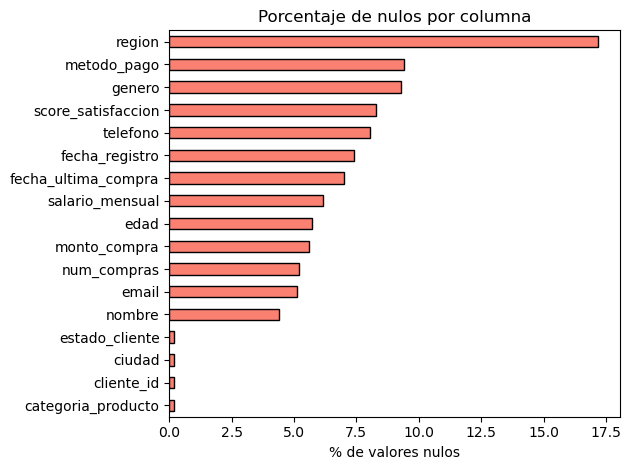

In [8]:
nulos_filtrado = nulos[nulos['nulos'] > 0]

nulos_filtrado['porcentaje'].sort_values().plot(
    kind='barh',
    color='salmon',
    edgecolor='black'
)

plt.title("Porcentaje de nulos por columna")
plt.xlabel('% de valores nulos')
plt.tight_layout()
plt.show()

In [9]:
filas_vacias = df[df.isnull().all(axis=1)]
print(f"filas completamente vacías: {len(filas_vacias)}")

filas completamente vacías: 10


In [10]:
#eliminación de filas vacías
df = df.dropna(how='all').reset_index(drop=True)
print(f'filas al elimnar vacías: {len(df):,}')

filas al elimnar vacías: 5,200


In [11]:
#Duplicados
total_dupli = df.duplicated().sum()
print(f"Filas completamente duplicadas: {total_dupli}")

Filas completamente duplicadas: 0


In [12]:
dupli_id = df[df.duplicated(subset='cliente_id', keep=False)]
print(f"filas con cliente_id duplicado: {len(dupli_id)}")

filas con cliente_id duplicado: 400


In [13]:
dupli_id.sort_values('cliente_id').head(8)

,cliente_id,nombre,email,telefono,edad,genero,ciudad,categoria_producto,monto_compra,salario_mensual,score_satisfaccion,metodo_pago,fecha_registro,fecha_ultima_compra,estado_cliente,num_compras,region
5149,5.0,Diana Martínez,usuario5@empresa.co,3122332274,68,MASCULINO,Barranquilla,ROPA,443061.61,3411873.42,6.5,pse,18 Nov 2020,05-28-2022,activo,38.0,Oriente
4,5.0,Sandra González,NaN,3158003954,54,Male,Bogotá,Alimentos,5327.67,3991891.30,2.2,Efectivo,22/05/2023,09-19-2022,Inactivo,33.0,Sur
26,27.0,Diana Rodríguez,usuario27@hotmail.com,3118704462,31,m,medellin,Hogar,266113.93,2125744.46,4.4,Efectivo,09-11-2023,01-03-2022,Pendiente,9.0,Oriente
5136,27.0,Sergio Rivera,usuario27@gmail.com,3154060146,30,MASCULINO,Medellín,electronica,38603.97,940780.72,9.4,TARJETA CREDITO,NaN,02 Jul 2021,activo,9.0,Oriente
53,54.0,Ana González,usuario54@yahoo.com,3015162905,34,MASCULINO,Santa Marta,Electrónica,153229.86,5724272.73,NaN,Tarjeta Crédito,08-01-2020,12 May 2021,Inactivo,19.0,Oriente
5027,54.0,Pedro Rodríguez,usuario54@gmail.com,3101179269,56,Masculino,Medellín,Alimentos,285461.18,4471992.30,7.6,Tarjeta Débito,10-23-2023,2024/02/20,ACTIVO,8.0,NaN
5194,59.0,Natalia Ramírez,usuario59gmail.com,3014039165,75,NaN,Bogotá,Ropa,15822.64,4141986.47,3.9,efectivo,2022-01-23,2022/07/04,Cancelado,42.0,Centro
58,59.0,María García,usuario59@yahoo.com,3156216033,54,Masculino,barranquilla,electronica,NaN,3168458.93,2.4,pse,2024/01/17,14 Jun 2024,pendiente,13.0,Centro


In [14]:
df = df.drop_duplicates(subset='cliente_id', keep='first').reset_index(drop=True)
print(f'filas al elimnar duplicados: {len(df):,}')

filas al elimnar duplicados: 5,000


In [15]:
#Limpieza de texto de ciudades
print('Ciudades únicas (sin limpiar): ')
print(sorted(df['ciudad'].dropna().unique()))

Ciudades únicas (sin limpiar): 
['  Cartagena  ', 'BOGOTA', 'Barranquilla', 'Bogotá', 'Bucaramanga', 'CALI', 'Cali', 'Cartagena', 'Cúcuta', 'Manizales', 'Medellín', 'Pereira', 'Santa Marta', 'barranquilla', 'medellin']


In [16]:
#Lsita de columnas de texto que requieren normalización

columnas_texto = ['ciudad', 'genero', 'categoria_producto', 'metodo_pago', 'estado_cliente', 'region']

for col in columnas_texto:
    df[col] = df[col].str.strip().str.title()
    

#verificamos el reusltado de ciudades
print("Ciudades únicas después de limpiar")
print(sorted(df['ciudad'].dropna().unique()))



Ciudades únicas después de limpiar
['Barranquilla', 'Bogota', 'Bogotá', 'Bucaramanga', 'Cali', 'Cartagena', 'Cúcuta', 'Manizales', 'Medellin', 'Medellín', 'Pereira', 'Santa Marta']


In [17]:
mapa_genero = {
    'M':     'Masculino',
    'F':     'Femenino',
    'Male':  'Masculino',
    'Female':'Femenino',
}

df['genero'] = df['genero'].replace(mapa_genero)


#Verficamos
df['genero'].value_counts(dropna=False)

genero
Femenino     2300
Masculino    2240
NaN           460
Name: count, dtype: int64

In [18]:
map_estado = {
    'Tarjeta Credito': 'Tarjeta de Crédito',
    'Tarjeta Crédito': 'Tarjeta de Crédito',
    'Pse': 'PSE'
}

df['metodo_pago'] = df['metodo_pago'].replace(map_estado)
print("\nMétodos de pago únicos después de corrección:")
df['metodo_pago'].value_counts(dropna=False)


Métodos de pago únicos después de corrección:


metodo_pago
Tarjeta de Crédito    1030
PSE                   1023
Tarjeta Débito         999
Efectivo               968
Nequi                  522
NaN                    458
Name: count, dtype: int64

# Conversión de Fechas

In [19]:
#Mostrar los formatos sucios
print('Muestra de fechas y formatos (antes de): ')
print(df['fecha_registro'].dropna().sample(10, random_state=1).to_list())

Muestra de fechas y formatos (antes de): 
['02/03/2021', '2020-07-26', '2020-12-05', '2024-06-18', '2024/02/16', '09 Nov 2022', '2024-05-07', '2020/08/31', '27 Nov 2022', '28/11/2022']


In [20]:
print(f"Cantidad de fechas que contienen '/': {df['fecha_registro'].str.contains('/').sum()}") # Verificar si hay fechas con formato MM/DD/YYYY
print(f"Cantidad de fechas que contienen '-': {df['fecha_registro'].str.contains('-').sum()}") # Verificar si hay fechas con formato YYYY-MM-DD o MM-DD-YYYY
print(f"Cantidad de fechas que contienen texto no numérico: {df['fecha_registro'].str.contains('[a-zA-Z]', na=False).sum()}") # Verificar si hay fechas con texto no numérico
print(f"Cantidad de fechas nulas: {df['fecha_registro'].isnull().sum()}") # Verificar cantidad de nulos en fecha_registro

Cantidad de fechas que contienen '/': 1556
Cantidad de fechas que contienen '-': 2329
Cantidad de fechas que contienen texto no numérico: 757
Cantidad de fechas nulas: 358


In [21]:
from dateutil import parser as dateutil_parser
import re

def detectar_patron(v):
    
    v = str(v).strip() #Convertir a String y quitar espacios al inicio y al final
    
    if re.match(r'^\d{4}[-/]\d{2}[-/]\d{2}$', v): return 'YYYY-MM-DD o YYYY/MM/DD'
    
    if re.match(r'^\d{2} [A-Za-z]{3} \d{4}$', v): return 'DD Mon YYYY'
    
    return f'otro: {v[:20]}' #Cualquier formator no contemplado o no estipulado y se muestre al final de todo



In [22]:
for col in ['fecha_registro', 'fecha_ultima_compra']:
    print(f" Formatos detectados en {col}")
    
    print(df[col].dropna().map(detectar_patron).value_counts().to_string())
    
    print(f" Nan Originales: {df[col].isna().sum()}\n")

 Formatos detectados en fecha_registro
fecha_registro
YYYY-MM-DD o YYYY/MM/DD    1535
DD Mon YYYY                 757
otro: 09-06-2022              6
otro: 11-06-2022              5
otro: 06-09-2022              5
otro: 07-12-2021              4
otro: 10/11/2023              4
otro: 05-03-2022              4
otro: 23/01/2023              4
otro: 12-12-2020              4
otro: 09-08-2020              4
otro: 01-08-2020              4
otro: 09-11-2023              3
otro: 13/05/2023              3
otro: 26-11-2021              3
otro: 20-04-2021              3
otro: 04-17-2024              3
otro: 03-04-2022              3
otro: 09-09-2023              3
otro: 03/07/2023              3
otro: 10/07/2024              3
otro: 07-04-2022              3
otro: 01-10-2022              3
otro: 21-03-2020              3
otro: 12-15-2020              3
otro: 01/04/2022              3
otro: 22-07-2020              3
otro: 12-12-2021              3
otro: 02-21-2020              3
otro: 10-21-2020  

In [23]:
df['fecha_registro'] = pd.to_datetime(
    df['fecha_registro'],
    format='mixed', #El mixed lo que hace es detectar el formato de cada valor individualmente
    dayfirst=True,
    errors='coerce'  #-> NaT
)

df['fecha_ultima_compra'] = pd.to_datetime(
    df['fecha_ultima_compra'],
    format='mixed',
    dayfirst=True,
    errors='coerce'  #-> NaT
)

In [24]:
#Verifcación por prints

print("Tipos de datos después")
print(df[['fecha_registro', 'fecha_ultima_compra']].dtypes)

print("\n NaT despúes de convertir")
for col in['fecha_registro', 'fecha_ultima_compra']:
    n = df[col].isna().sum()
    print(f" {col}: {n} NaT ({n/len(df)*100:.1f}%)")
    

print("\n Rango de fechas")
for col in ['fecha_registro', 'fecha_ultima_compra']:
    print(f" {col}: {df[col].min().date()} -> {df[col].max().date()}")



Tipos de datos después
fecha_registro         datetime64[us]
fecha_ultima_compra    datetime64[us]
dtype: object

 NaT despúes de convertir
 fecha_registro: 358 NaT (7.2%)
 fecha_ultima_compra: 338 NaT (6.8%)

 Rango de fechas
 fecha_registro: 2020-01-01 -> 2024-12-30
 fecha_ultima_compra: 2020-01-01 -> 2024-12-30


In [25]:
#Una vez que ya usamos y convetrimos a datetime, podemos extraer los componentes con el accesor .dt

df['anio_registro'] = df['fecha_registro'].dt.year
df['mes_registro'] = df['fecha_registro'].dt.month
df['dia_semana'] = df['fecha_registro'].dt.day_name()

df['dias_entre_eventos'] = (df['fecha_ultima_compra'] - df['fecha_registro']).dt.days

#Mostramos el resultado
df[['fecha_registro', 'anio_registro', 'mes_registro', 'dia_semana', 'dias_entre_eventos']].head()

,fecha_registro,anio_registro,mes_registro,dia_semana,dias_entre_eventos
0,2020-04-03,2020.0,4.0,Friday,1008.0
1,2022-01-17,2022.0,1.0,Monday,-568.0
2,2020-11-01,2020.0,11.0,Sunday,1337.0
3,2022-10-03,2022.0,10.0,Monday,108.0
4,2023-05-22,2023.0,5.0,Monday,-245.0


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   cliente_id           5000 non-null   float64       
 1   nombre               4789 non-null   str           
 2   email                4753 non-null   str           
 3   telefono             4604 non-null   str           
 4   edad                 4723 non-null   str           
 5   genero               4540 non-null   str           
 6   ciudad               5000 non-null   str           
 7   categoria_producto   5000 non-null   str           
 8   monto_compra         4730 non-null   float64       
 9   salario_mensual      4703 non-null   float64       
 10  score_satisfaccion   4596 non-null   float64       
 11  metodo_pago          4542 non-null   str           
 12  fecha_registro       4642 non-null   datetime64[us]
 13  fecha_ultima_compra  4662 non-null   datetim

## Limpieza de colunmas numéricas





In [27]:
columnas_numericas = ["edad", "monto_compra", "salario_mensual", "score_satisfaccion", "num_compras" ]

for i in columnas_numericas:
    df[i] = pd.to_numeric(df[i], errors='coerce')

df[columnas_numericas].dtypes

edad                  float64
monto_compra          float64
salario_mensual       float64
score_satisfaccion    float64
num_compras           float64
dtype: object

In [28]:
#Estadisiticas antes de limpiar
df[columnas_numericas].describe().round(2)

,edad,monto_compra,salario_mensual,score_satisfaccion,num_compras
count,4697.00,4730.00,4703.00,4596.00,4746.00
mean,53.29,494152.90,4481268.48,5.92,25.60
std,81.73,2958116.82,10182698.70,7.46,14.43
min,-5.00,5012.71,-348511.09,-1.00,1.00
25%,32.00,79494.89,2636858.84,3.10,13.00
50%,47.00,183123.49,3473547.69,5.40,26.00
75%,61.00,364727.76,4308563.50,7.80,38.00
max,999.00,85744042.00,99999999.00,100.00,50.00


In [29]:
#Between(18, 100, 'edad') = np.nan   #entre 18 y 100
#loc

#Remmplazo de valroes fuera de rango

df.loc[~df['edad'].between(18,100), 'edad']  = np.nan 
df.loc[~df['salario_mensual'].between(0, 50_000_000), 'salario_mensual']  = np.nan 
df.loc[~df['score_satisfaccion'].between(1, 10), 'score_satisfaccion']  = np.nan 
df.loc[~df['monto_compra'].between(1, 50_000_000), 'monto_compra']  = np.nan 

#Nulos actuales en columnas numericas (Incluyend los que ya existina + los recién creados)
df[columnas_numericas].isnull().sum()

edad                  410
monto_compra          274
salario_mensual       411
score_satisfaccion    510
num_compras           254
dtype: int64

In [31]:
# Imputar nulos numéricos con la MEDIANA de cada columna

for col in columnas_numericas:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana) #Rellenar NaN con esa mediana

#confirmación
print('Nulos en columnas numéricas:', df[columnas_numericas].isnull().sum().sum())

Nulos en columnas numéricas: 0


In [32]:
#imputación de nulos en columnas categoricas

for col in columnas_texto:
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda) #Rellenar NaN de categóricos con la moda calculada

#confirmación
print('Nulos en columnas categoricas:', df[columnas_texto].isnull().sum().sum())


Nulos en columnas categoricas: 0


## Detección Visual de Outliers

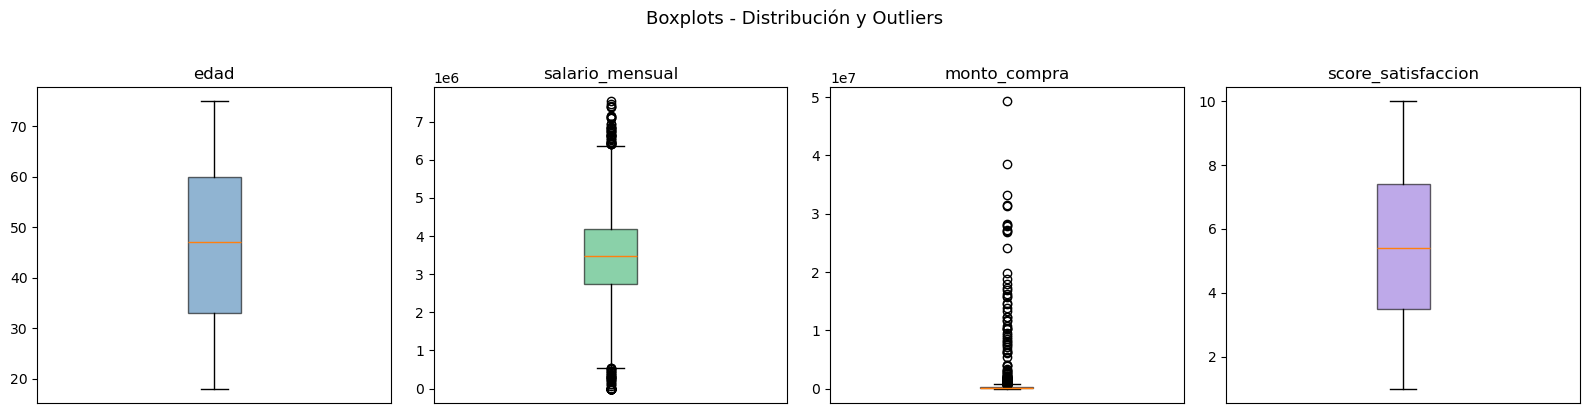

In [36]:
cols_box = ['edad', 'salario_mensual', 'monto_compra', 'score_satisfaccion']
colores = ['steelblue', 'mediumseagreen', 'tomato', 'mediumpurple']

fig, axes = plt.subplots(1, 4, figsize=(16,4))

for ax, col, color in zip(axes, cols_box, colores):
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6)
    )
    
    ax.set_title(col)
    ax.set_xticks([])

plt.suptitle('Boxplots - Distribución y Outliers', fontsize=13, y=1.02)
plt.tight_layout()

plt.show()

## Análisis Univariado

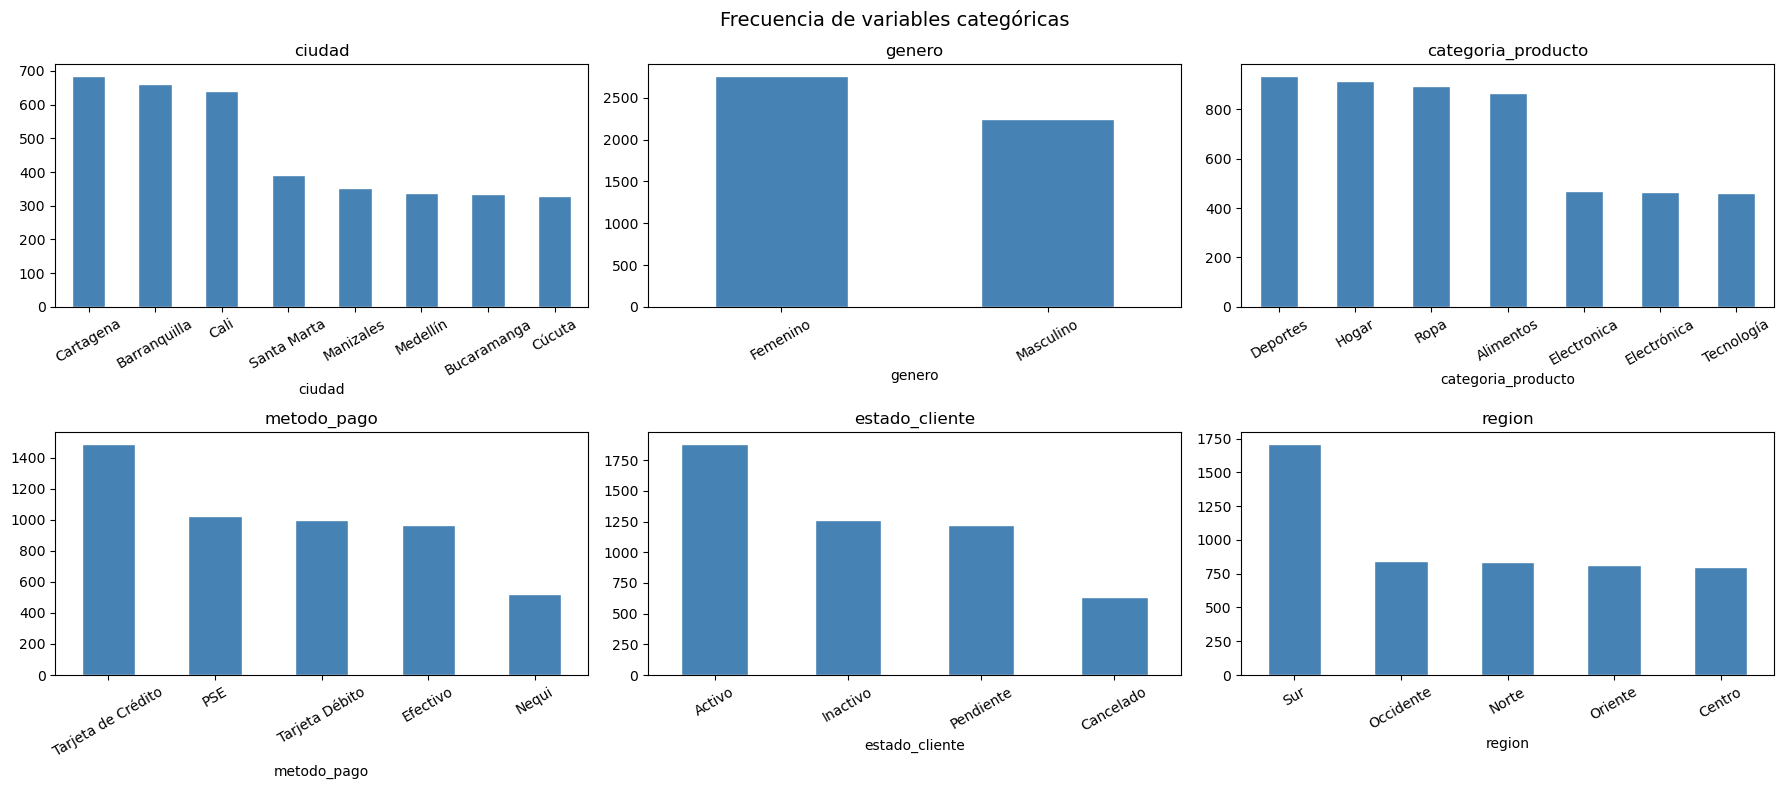

In [52]:
#Barras de frecuencia para cada variable categórica

fig, axes = plt.subplots(2,3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(columnas_texto):
    conteo = df[col].value_counts().head(8)  #Top 8 categorías más frecuentes
    conteo.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis= 'x', rotation=30)


plt.suptitle('Frecuencia de variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

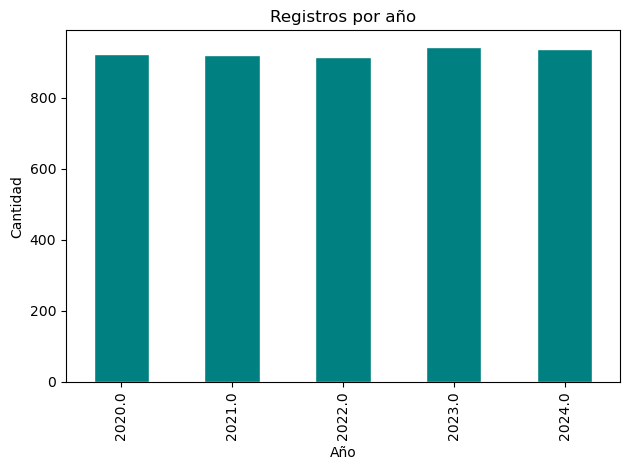

In [58]:
#Distribución de registros por año de actividad comercial

df['anio_registro'].value_counts().sort_index().plot(
    kind='bar',
    color='teal',
    edgecolor='white'
)

plt.title('Registros por año')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.tight_layout()

plt.show()

## Análisis Bivariado

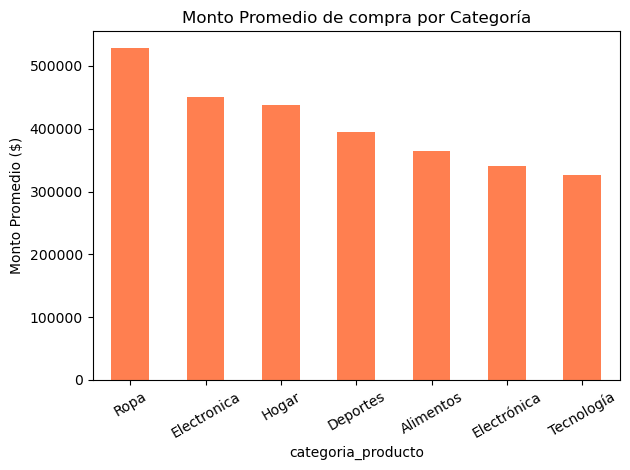

In [64]:
#Monto promedio de compra por categoría de producto

(
    df.groupby('categoria_producto')['monto_compra']
    .mean()
    .sort_values(ascending=False)
    .plot(kind='bar', color='coral')
)

plt.title('Monto Promedio de compra por Categoría')
plt.ylabel('Monto Promedio ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()